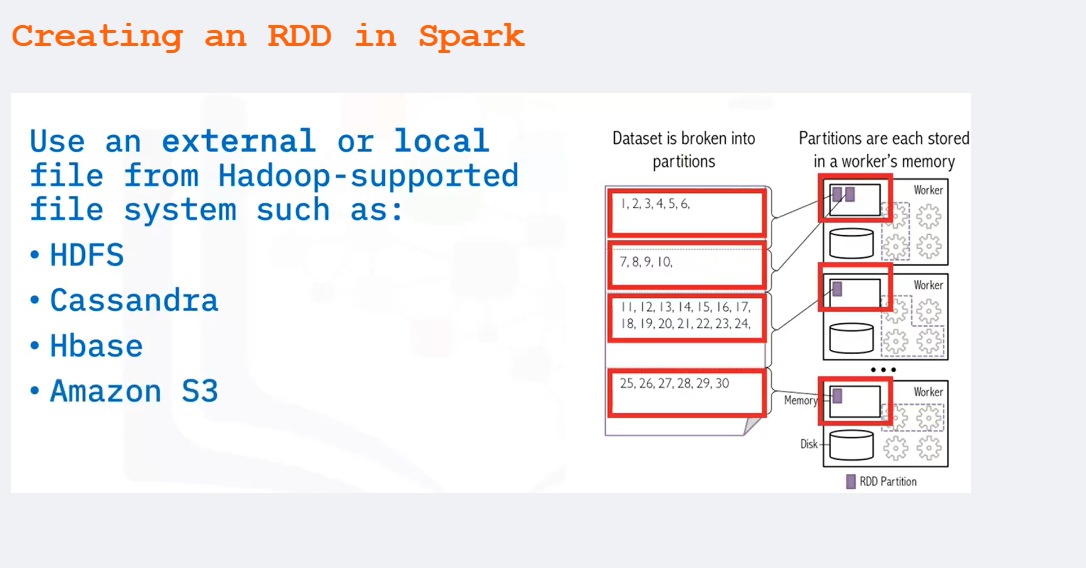

# RDD Operations in PySpark

## Introduction to RDDs

Resilient Distributed Datasets (RDDs) form the fundamental building blocks of Apache Spark. Think of an RDD as a distributed collection of data that can be processed in parallel across multiple machines. The "resilient" part means that if any part of your data is lost due to hardware failure, Spark can automatically recover it.

RDDs are immutable, which means once created, they cannot be changed. Instead, operations on RDDs create new RDDs. This immutability is crucial for fault tolerance and enables Spark to track the lineage of transformations, allowing it to rebuild lost partitions.

## Types of RDD Operations

RDD operations fall into two main categories, and understanding this distinction is fundamental to working effectively with Spark:

### 1. Transformations (Lazy Operations)

Transformations are operations that create a new RDD from an existing one. They are "lazy," meaning they don't execute immediately when called. Instead, Spark builds up a computation graph and only executes it when an action is triggered. This lazy evaluation allows Spark to optimize the entire computation pipeline.

### 2. Actions (Eager Operations)

Actions are operations that trigger the execution of transformations and return results to the driver program or write data to external storage. When you call an action, Spark executes all the transformations in the lineage to produce the final result.

In [2]:
from pyspark import SparkContext, SparkConf

# Initialize Spark context
conf = SparkConf().setAppName("RDD_Operations_Demo")
sc = SparkContext(conf=conf)

# Create an RDD from a list
numbers = sc.parallelize([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
numbers2 = sc.parallelize(range(1,11))


---

## Side note n `map()`, `filter()`, and `reduce()` in Python


### `filter(), map(), and reduce()`

The built-in filter(), map(), and reduce() functions are all common in functional programming.

It’s important to understand these functions in a core Python context. Then, you’ll be able to translate that knowledge into PySpark programs and the Spark API.

1. `filter()` filters items out of an iterable based on a condition, typically expressed as a lambda function:

In [5]:
x = ['Python', 'programming', 'is', 'awesome!']

# list(filter(lambda arg: len(arg) < 8, x))


def filter_func(arg):
    return len(arg) < 8

list(filter(filter_func, x))

['Python', 'is']

Note: Calling list() is required because filter() is also an iterable. filter() only gives you the values as you loop over them. list() forces all the items into memory at once instead of having to use a loop.

In [6]:
def is_less_than_8_characters(item):
    return len(item) < 8

x = ['Python', 'programming', 'is', 'awesome!']
results = []

for item in x:
    if is_less_than_8_characters(item):
        results.append(item)

print(results)

['Python', 'is']


2.` map()` is similar to filter() in that it applies a function to each item in an iterable, but it always produces a 1-to-1 mapping of the original items. The new iterable that map() returns will always have the same number of elements as the original iterable, which was not the case with filter():

In [8]:
org = ['Python', 'prOgramming', 'is', 'aWesoMe!']


print(list(map(lambda arg: arg.lower(), x)))

['python', 'programming', 'is', 'awesome!']


3. `reduce()`

Finally, the last of the functional trio in the Python standard library is reduce(). As with filter() and map(), reduce() applies a function to elements in an iterable.

Again, the function being applied can be a standard Python function created with the def keyword or a lambda function.

However, reduce() doesn’t return a new iterable. Instead, reduce() uses the function called to reduce the iterable to a single value:


In [9]:
from functools import reduce

x = ['Python', 'programming', 'is', 'awesome!']

print(reduce(lambda val1, val2: val1 + val2, x))

Pythonprogrammingisawesome!


In [10]:
nums = [1,2,3,4,5]

reduce(lambda x,y: x+y, nums)

15

---

## Transformations

### 1. map() - One-to-One Transformation

The map transformation applies a function to each element in the RDD and returns a new RDD with the transformed elements.

In [ ]:
from pyspark import SparkContext, SparkConf

# Initialize Spark context
conf = SparkConf().setAppName("RDD_Operations_Demo")
sc = SparkContext(conf=conf)




In [11]:
# Create an RDD from a list
numbers = sc.parallelize([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

In [12]:
type(numbers)

pyspark.rdd.RDD

In [14]:
squared_numbers = numbers.map(lambda x: x ** 2)
print("Original:", numbers.collect())
print("Squared:", squared_numbers.collect())


Original: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Squared: [1, 4, 9, 16, 25, 36, 49, 64, 81, 100]


In [15]:
words = sc.parallelize(["hello", "world", "spark", "rdd"])
upper_words = words.map(lambda word: word.upper())
print("Uppercase:", upper_words.collect())

Uppercase: ['HELLO', 'WORLD', 'SPARK', 'RDD']


### 2. filter() - Selective Transformation

The filter transformation returns a new RDD containing only elements that satisfy a given condition.

In [16]:
even_numbers = numbers.filter(lambda x: x % 2 == 0)
print("Even numbers:", even_numbers.collect())

Even numbers: [2, 4, 6, 8, 10]


In [17]:
long_words = words.filter(lambda word: len(word) > 4)
print("Long words:", long_words.collect())

Long words: ['hello', 'world', 'spark']


### 3. flatMap() - One-to-Many Transformation

The flatMap transformation is similar to map, but each input element can be mapped to zero or more output elements. The results are flattened into a single RDD.

In [18]:
sentences = sc.parallelize(["Hello world", "Apache Spark", "RDD operations"])


words_flat = sentences.flatMap(lambda sentence: sentence.split(" "))
print("Flattened words:", words_flat.collect())

Flattened words: ['Hello', 'world', 'Apache', 'Spark', 'RDD', 'operations']


In [19]:
words_map_wo_flat = sentences.map(lambda sentence: sentence.split(" "))
print("Flattened words:", words_map_wo_flat.collect())

Flattened words: [['Hello', 'world'], ['Apache', 'Spark'], ['RDD', 'operations']]


In [20]:
l1 = ["Hello world", "Apache Spark", "RDD operations"]

for i in l1:
    print(i.split(" "))

['Hello', 'world']
['Apache', 'Spark']
['RDD', 'operations']


## Set Operations

RDDs support mathematical set operations that are particularly useful for data analysis:

In [21]:
rdd1 = sc.parallelize([1, 2, 3, 4, 5])
rdd2 = sc.parallelize([4, 5, 6, 7, 8])

# 1. union()
union_result = rdd1.union(rdd2)
print("Union:", union_result.collect())



Union: [1, 2, 3, 4, 5, 4, 5, 6, 7, 8]


In [22]:
# 2. distinct_union()
distinct_union = rdd1.union(rdd2).distinct()
print("Distinct Union:", distinct_union.collect())

Distinct Union: [4, 8, 1, 5, 2, 6, 3, 7]


In [23]:
# 3. intersection()

intersection_result = rdd1.intersection(rdd2)
print("Intersection:", intersection_result.collect())

Intersection: [4, 5]


In [24]:
# 4. subtract()

subtract_result = rdd1.subtract(rdd2)
print("Subtract:", subtract_result.collect())

Subtract: [1, 2, 3]


---

**mapPartitions(func)**
   - **Description**: Applies a function to each partition of the RDD.
   - **Use Case**: To apply a transformation at the partition level.
   - **Example**:


---

In [30]:
numbers3 = sc.parallelize([1,2,3,4,5,6,7,8,9,10], 2)

numbers3.getNumPartitions()



2

In [31]:
result = numbers3.mapPartitions(lambda iter: [sum(iter)]).collect()
print(result)

[15, 40]


**distinct()**
   - **Description**: Returns a new RDD with distinct elements.
   - **Use Case**: To remove duplicate elements from a dataset.
   - **Example**:

   

In [32]:
rdd = sc.parallelize([1, 2, 2, 3, 4, 4, 5])
result = rdd.distinct().collect()
print(result)

[2, 4, 1, 3, 5]


### Advanced Transformations

#### `groupByKey()` and `reduceByKey()`

These operations work with key-value pair RDDs and are fundamental for aggregation operations:

In [35]:
sales_data = sc.parallelize([
    ("laptop", 1000), ("mouse", 25), ("laptop", 1200),
    ("keyboard", 75), ("mouse", 30), ("laptop", 800)
])

# groupByKey groups values by key
grouped_sales = sales_data.groupByKey()
grouped_sales.mapValues(list).collect()

[('laptop', [1000, 1200, 800]), ('mouse', [25, 30]), ('keyboard', [75])]

In [36]:
total_sales = sales_data.reduceByKey(lambda x, y: x + y)
print("Total sales by product:", total_sales.collect())

Total sales by product: [('laptop', 3000), ('mouse', 55), ('keyboard', 75)]


> The key difference between these operations is efficiency: reduceByKey performs local aggregation before shuffling data across the network, making it much faster for large datasets than groupByKey followed by a reduction.


#### join() Operations

Join operations combine two key-value RDDs based on their keys:

In [37]:
products = sc.parallelize([("laptop", "Electronics"), ("mouse", "Electronics"), ("book", "Media")])
prices = sc.parallelize([("laptop", 1000), ("mouse", 25), ("tablet", 300)])

In [39]:
# Inner join - only keys present in both RDDs
inner_joined = prices.join(products)
print("Inner join:", inner_joined.collect())


Inner join: [('laptop', (1000, 'Electronics')), ('mouse', (25, 'Electronics'))]


In [40]:
# Left outer join - all keys from left RDD
left_joined = products.leftOuterJoin(prices)
print("Left outer join:", left_joined.collect())

Left outer join: [('laptop', ('Electronics', 1000)), ('mouse', ('Electronics', 25)), ('book', ('Media', None))]


In [41]:
# Right outer join - all keys from right RDD
right_joined = products.rightOuterJoin(prices)
print("Right outer join:", right_joined.collect())

Right outer join: [('laptop', ('Electronics', 1000)), ('mouse', ('Electronics', 25)), ('tablet', (None, 300))]


## Actions
## Action Operations

Actions trigger the execution of transformations and return results. Here are the most commonly used actions:

In [42]:
sample_numbers = sc.parallelize([1, 2, 3, 4, 5, 4, 3, 2, 1])

# 1. collect() - returns all elements as a list (use carefully with large datasets)
all_elements = sample_numbers.collect()

print("All elements:", all_elements)

All elements: [1, 2, 3, 4, 5, 4, 3, 2, 1]


In [43]:
# 2. count() - returns the number of elements
element_count = sample_numbers.count()
print("Count:", element_count)

Count: 9


In [44]:
# 3. first() - returns the first element
first_element = sample_numbers.first()
print("First element:", first_element)

First element: 1


In [45]:
# 4. take(n) - returns first n elements
first_three = sample_numbers.take(3)
print("First three:", first_three)

First three: [1, 2, 3]


In [46]:
# 5. top(n) - returns top n elements in descending order
top_three = sample_numbers.top(3)
print("Top three:", top_three)

Top three: [5, 4, 4]


### Aggregation Functions

In [47]:

# Mathematical aggregations
sum_result = sample_numbers.sum()
print("Sum:", sum_result)

Sum: 25


In [48]:
# reduce() - applies a function to reduce all elements to a single value
max_value = sample_numbers.reduce(lambda x, y: x if x > y else y)
print("Maximum:", max_value)

Maximum: 5


In [49]:
nums2 = sc.parallelize(range(1,11))
total = nums2.reduce(lambda x, y: x + y)
print("Total:", total)

Total: 55


In [52]:
# fold() - similar to reduce but with an initial value
sample_nums = sc.parallelize(range(1,11))
print("Number of partitoins: ",sample_nums.getNumPartitions())
sum_with_initial = sample_nums.fold(10, lambda x, y: x+y)
print("Sum with initial 10:", sum_with_initial)


Number of partitoins:  2
Sum with initial 10: 85


> The actual calculation becomes: (sum of all elements) + (initial_value × number_of_partitions) + initial_value


**When fold() Becomes Necessary**

The key limitation of `reduce()` is that it requires your RDD to have at least one element. If you try to call `reduce()` on an empty RDD, Spark will throw an exception because there's nothing to reduce. This is where `fold()` becomes valuable, because it can handle empty RDDs gracefully by returning the initial value.

Consider this scenario: you're processing daily sales data, but some days might have no sales at all. With `reduce()`, your code would crash on those empty days. With `fold()` and a proper identity element, you'd get a sensible default result.

In [53]:
rdd = sc.parallelize([1, 2, 3, 4, 5])
result = rdd.fold(0, lambda x, y: x + y)
print(result)

15


**foreach(func)**
- **Description**: Applies a function to each element of the RDD or DataFrame.
- **Use Case**: For side effects, such as writing to a database or updating an accumulator.
- **Example**:

In [54]:
rdd = sc.parallelize(["py", "pi", "py", "sy", "sai", "sai", "sai"], 4)
rdd.getNumPartitions()

4

In [57]:
rdd = sc.parallelize(["py", "pi", "py", "sy", "sai", "sai", "sai"])



def print_element(x):
  print(x)

rdd.foreach(print_element)



"""

When you run rdd.foreach(print_element) in Spark, the print statements execute
on the worker nodes (the machines that actually process your data), not on the
driver program where you're running your code. This means the output gets
printed to the worker node logs, not to your console or notebook output.

Why This Happens
Spark is designed for distributed computing. Your RDD is partitioned across
multiple worker nodes, and when you call foreach, each worker processes its
portion of the data independently. The print function executes locally on each
worker, so the output appears in the worker logs rather than being collected
back to your driver program.

"""


"\n\nWhen you run rdd.foreach(print_element) in Spark, the print statements execute\non the worker nodes (the machines that actually process your data), not on the\ndriver program where you're running your code. This means the output gets\nprinted to the worker node logs, not to your console or notebook output.\n\nWhy This Happens\nSpark is designed for distributed computing. Your RDD is partitioned across\nmultiple worker nodes, and when you call foreach, each worker processes its\nportion of the data independently. The print function executes locally on each\nworker, so the output appears in the worker logs rather than being collected\nback to your driver program.\n\n"

**The Primary Purpose of foreach()**

The `foreach()` action exists specifically for performing **side effects** on each element of your RDD without returning any data back to your driver program.
> Think of it as Spark's way of saying "go do something with each piece of data, but I don't need you to report back what you did."

This might seem strange at first, especially coming from regular Python programming where you expect functions to return results. But in distributed computing, there are many scenarios where you want to process data without collecting results back to a central location.


**Understanding Side Effects in Distributed Systems**
A side effect is any operation that changes something outside of the function itself, rather than just returning a value. In the context of distributed data processing, side effects typically involve interacting with external systems or resources.




In [58]:
# This function runs on multiple worker nodes simultaneously
def process_on_worker(data_chunk):
    # This print statement appears in the worker node logs, not your console
    print(f"Worker processing: {data_chunk}")
    # This file gets written on whichever worker is processing this chunk
    with open(f"/tmp/worker_output_{data_chunk}.txt", "w") as f:
        f.write(f"Processed {data_chunk}")

rdd = sc.parallelize(["py", "pi", "py", "sy", "sai", "sai", "sai"])
rdd.foreach(process_on_worker)


**countByKey()**
- **Description**: For an RDD of (K, V) pairs, returns a dictionary of (K, Int) pairs with the count of each key.
- **Use Case**: To count occurrences of each key.
- **Example**:

In [59]:
rdd = sc.parallelize([('a', 1), ('b', 1), ('a', 1), ('a', 55)])
result = rdd.countByKey()

print(result)
for k, v in  result.items():
  print(k, v)

defaultdict(<class 'int'>, {'a': 3, 'b': 1})
a 3
b 1


**countByValue()**
- **Description**: Returns a dictionary of (value, count) pairs, similar to `countByKey` but for values.
- **Use Case**: To count occurrences of each value.
- **Example**:

In [60]:
rdd = sc.parallelize(["py", "pi", "py", "sy", "sai", "sai", "sai"])
result = rdd.countByValue()
print(result)

for k, v in  result.items():
  print(k, v)

defaultdict(<class 'int'>, {'py': 2, 'pi': 1, 'sy': 1, 'sai': 3})
py 2
pi 1
sy 1
sai 3


In [62]:
rdd = sc.parallelize([1, 2, 3, 4, 5],4)
rdd.saveAsTextFile("/contents/sample.txt") #action

In [ ]:
"""

sales by each department

sales
Marketing
Tech
Engg

"""
# sum(sales)